# CNN & Final Comparison

**Level:** Advanced  
**Dataset:** MNIST  
**Goal:** Build a Convolutional Neural Network that exploits the spatial structure of images, visualise what the filters actually learn, and close with a full comparison across all three approaches: NumPy from scratch, Keras Dense, and CNN.

CNNs are not magic — they are a structured way to reuse learned patterns across all positions in an image.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams['figure.dpi'] = 130
IMG = '../images/'
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


In [2]:
with open('../data/nb2_artifacts.pkl', 'rb') as f:
    arts = pickle.load(f)

X_train_flat = arts['X_train']
X_test_flat  = arts['X_test']
y_train = arts['y_train']
y_test  = arts['y_test']
X_test_raw = arts['X_test_raw']
scratch_acc  = arts['scratch_acc']
acc_best_keras = arts['acc_best_keras']

# Reshape for CNN: (N, 28, 28, 1)
X_train_cnn = X_train_flat.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_flat.reshape(-1,  28, 28, 1)

print(f'CNN input shape: {X_train_cnn.shape}')
print(f'Baselines — Scratch: {scratch_acc*100:.2f}%  |  Best Keras Dense: {acc_best_keras*100:.2f}%')

CNN input shape: (60000, 28, 28, 1)
Baselines — Scratch: 96.30%  |  Best Keras Dense: 98.08%


## 1. Why CNNs?

**Why?** A dense network sees a 784-dimensional vector — it has no idea that pixel[0] is adjacent to pixel[1]. CNNs use convolutional filters that slide across the image, detecting local patterns (edges, curves) regardless of position. This *parameter sharing* is why a CNN with 50k parameters can outperform a dense network with 200k parameters on image tasks.

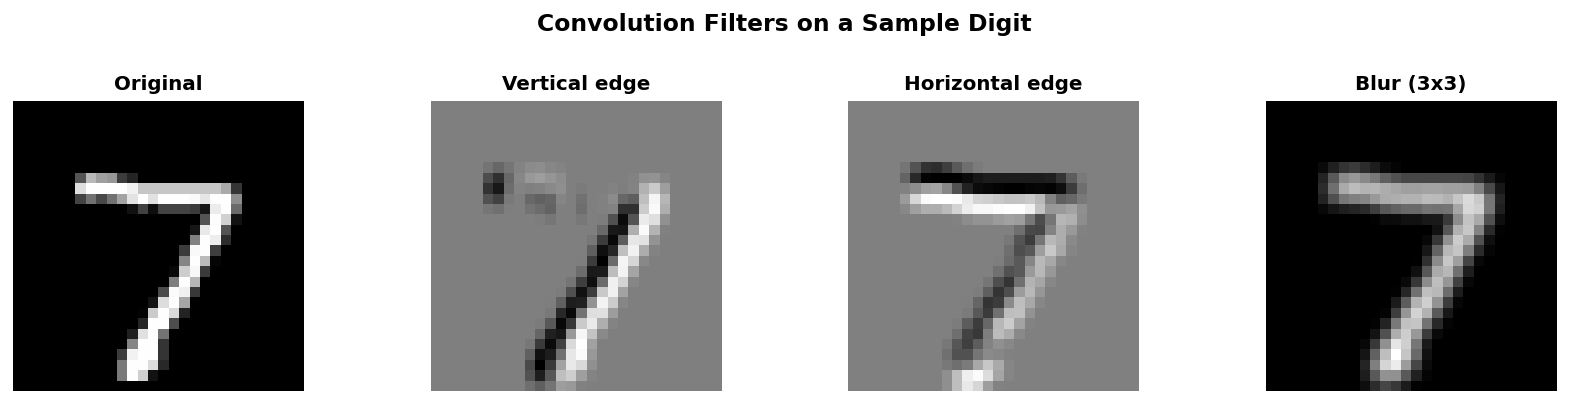

In [3]:
# Visualise what convolution does: apply a simple edge-detection filter manually
from scipy.ndimage import convolve

sample_img = X_test_raw[0].astype(np.float32) / 255.0

filters = {
    'Original':       sample_img,
    'Vertical edge':  convolve(sample_img, [[-1,0,1],[-2,0,2],[-1,0,1]]),
    'Horizontal edge':convolve(sample_img, [[-1,-2,-1],[0,0,0],[1,2,1]]),
    'Blur (3x3)':     convolve(sample_img, np.ones((3,3))/9),
}

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, (name, img) in zip(axes, filters.items()):
    ax.imshow(img, cmap='gray')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Convolution Filters on a Sample Digit', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG + '03_convolution_demo.png', bbox_inches='tight')
plt.show()

> **Key insight:** The vertical edge filter highlights vertical strokes; the horizontal filter highlights horizontal ones. A CNN learns *optimal* filters for the task — not hand-crafted ones like these. After training, the first layer's filters often look like edge detectors, and deeper layers combine those into curves and shapes.

## 2. Build the CNN

**Why?** Our architecture follows the classic pattern: alternating Conv→ReLU→MaxPool blocks followed by a dense head. MaxPooling reduces spatial dimensions (cutting computation) while retaining the most activated features. Two conv blocks give us two levels of abstraction — edges in block 1, shapes in block 2.

In [4]:
def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Block 1 — learn edges and simple textures
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),       # 28x28 → 14x14
        layers.Dropout(0.25),

        # Block 2 — combine edges into shapes
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),       # 14x14 → 7x7
        layers.Dropout(0.25),

        # Dense head — classify
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax'),
    ], name='cnn')

    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn = build_cnn()
cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [5]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
hist_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=30, batch_size=128,
    callbacks=[es], verbose=1
)
acc_cnn = cnn.evaluate(X_test_cnn, y_test, verbose=0)[1]
print(f'\nCNN test accuracy: {acc_cnn*100:.2f}%')

Epoch 1/30


  1/469 ━━━━━━━━━━━━━━━━━━━━ 7:01 902ms/step - accuracy: 0.1250 - loss: 4.1684

  4/469 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.1302 - loss: 3.5201  

  7/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.1495 - loss: 3.1902

 10/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.1673 - loss: 2.9837

...

463/469 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9856 - loss: 0.0500

466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9856 - loss: 0.0501

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9856 - loss: 0.0501

469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9843 - loss: 0.0527 - val_accuracy: 0.9918 - val_loss: 0.0282



CNN test accuracy: 99.30%


## 3. Visualise Learned Filters & Feature Maps

**Why?** CNNs are often described as black boxes, but the first layer's filters are directly interpretable. Visualising them — and the feature maps they produce — shows us what the network actually learned to look for. This builds intuition about *why* CNNs work, not just *that* they work.

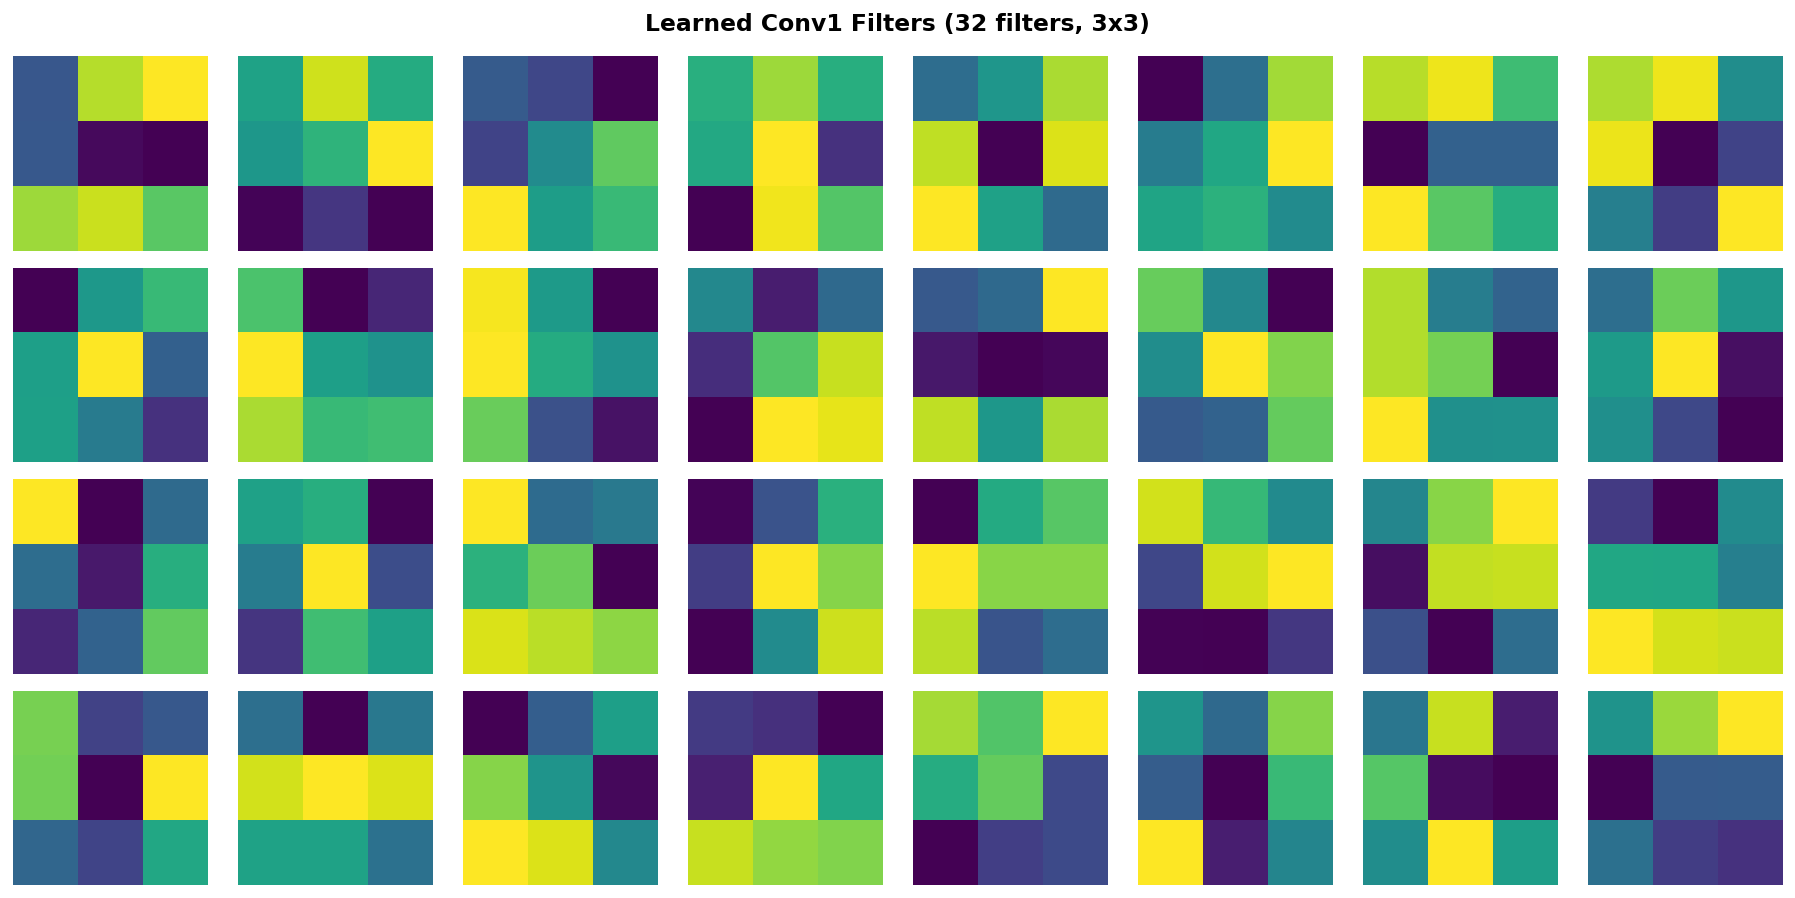

In [6]:
# First Conv2D layer filters — find by type to be robust across Keras versions
conv1 = next(l for l in cnn.layers if isinstance(l, layers.Conv2D))
filters_learned = conv1.get_weights()[0]  # shape: (3, 3, 1, 32)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    f = filters_learned[:, :, 0, i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f, cmap='viridis')
    ax.axis('off')

plt.suptitle('Learned Conv1 Filters (32 filters, 3x3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '03_learned_filters.png', bbox_inches='tight')
plt.show()


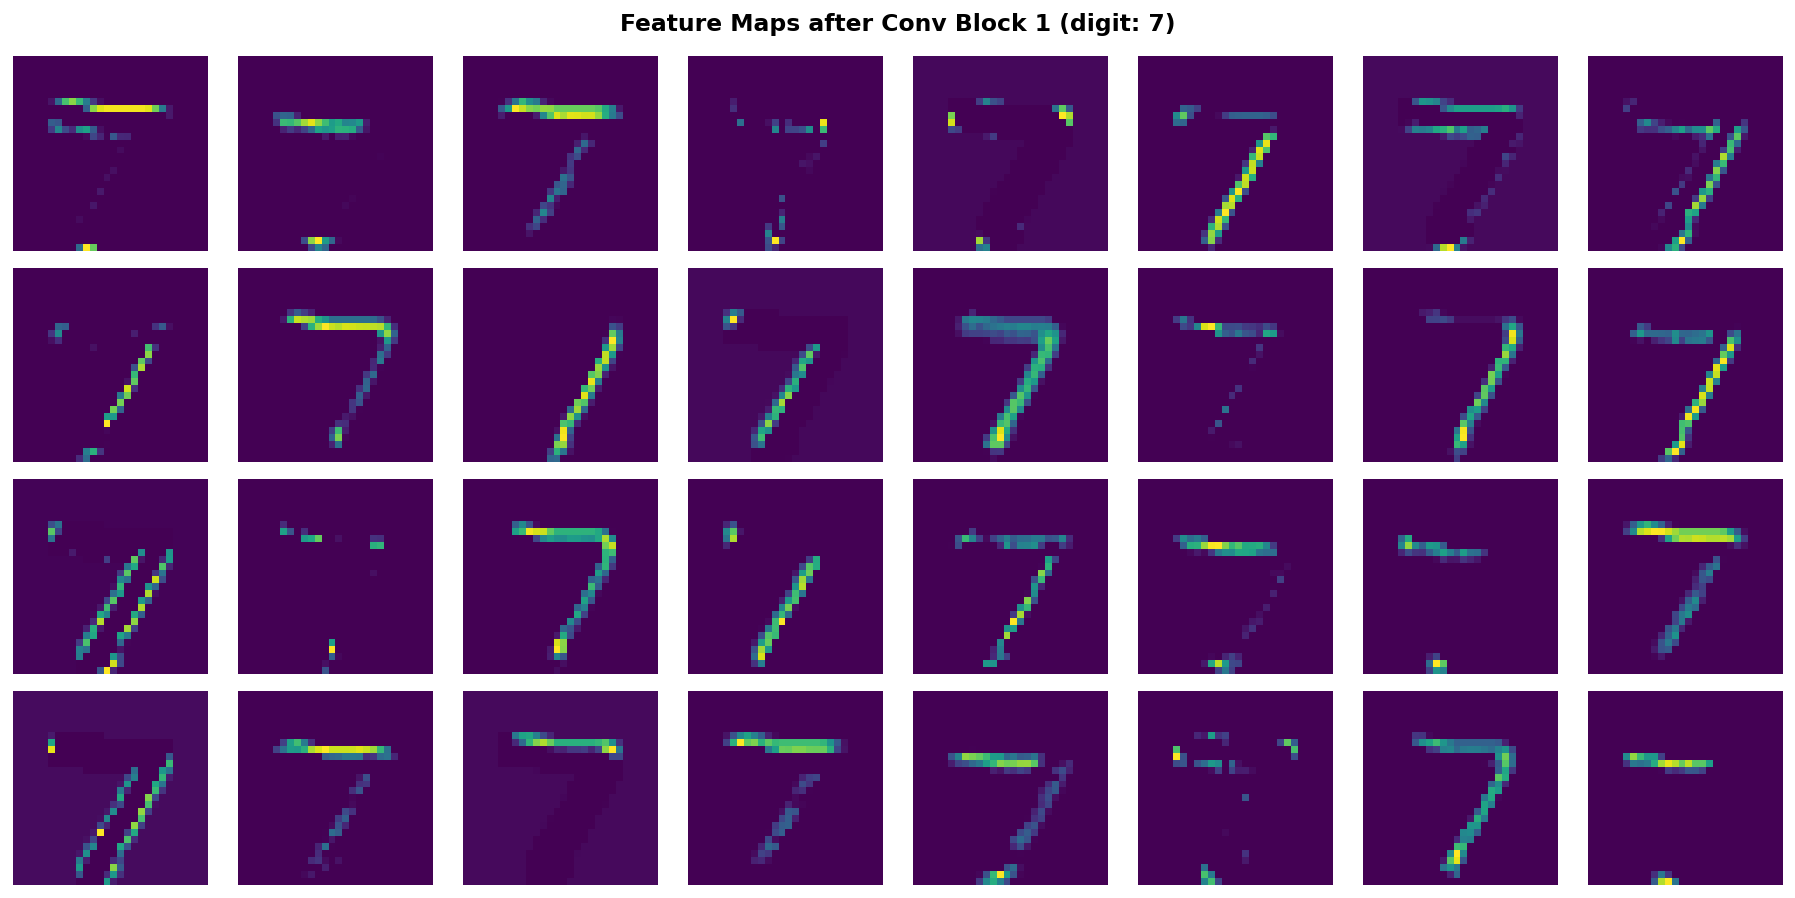

In [7]:
# Feature maps — use a sub-model from input up to first Activation layer
activation_layers = [l for l in cnn.layers if isinstance(l, layers.Activation)]
first_activation = activation_layers[0]

feature_model = keras.Model(inputs=cnn.inputs, outputs=first_activation.output)
sample = X_test_cnn[0:1]
feature_maps = feature_model.predict(sample, verbose=0)[0]

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[:, :, i], cmap='viridis')
    ax.axis('off')

plt.suptitle(f'Feature Maps after Conv Block 1 (digit: {y_test[0]})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '03_feature_maps.png', bbox_inches='tight')
plt.show()


> **Key insight:** Each feature map highlights a different aspect of the input — some respond to horizontal strokes, some to curves, some to diagonal edges. The network learned these without being told what edges or curves are. This is the core idea of representation learning: let the data and the loss function determine what features matter.

## 4. CNN Confusion Matrix

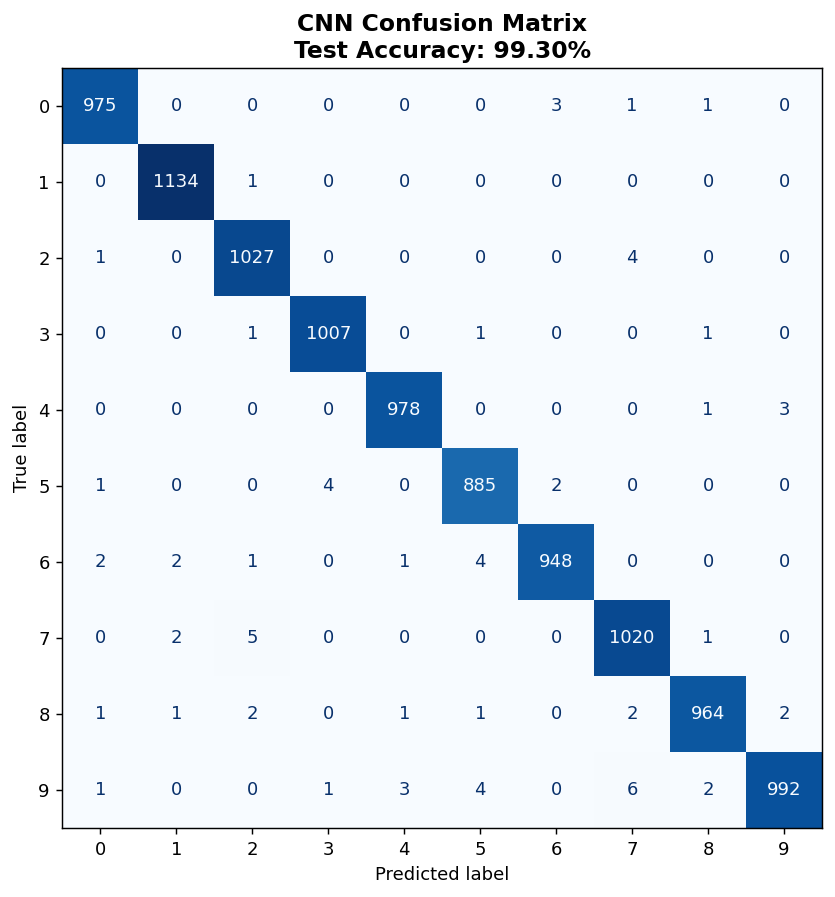

In [8]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn, verbose=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'CNN Confusion Matrix\nTest Accuracy: {acc_cnn*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '03_cnn_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 5. Final Comparison — All Three Approaches

**Why?** We built the same classifier three different ways. The comparison quantifies exactly how much architectural complexity buys us in accuracy, and makes the tradeoffs visible: more expressive architecture → higher accuracy, but also more hyperparameters to tune and longer training time.

In [9]:
comparison = {
    'NumPy from Scratch': {'acc': scratch_acc,    'params': '~235k', 'framework': 'NumPy only'},
    'Keras Dense':        {'acc': acc_best_keras,  'params': '~235k', 'framework': 'Keras + BN + Dropout + Adam'},
    'CNN':                {'acc': acc_cnn,          'params': '~93k',  'framework': 'Keras Conv2D'},
}

print(f'{"Model":<25} {"Accuracy":>10}  {"Params":>8}  Notes')
print('-' * 70)
for name, d in comparison.items():
    print(f'{name:<25} {d["acc"]*100:>9.2f}%  {d["params"]:>8}  {d["framework"]}')

Model                       Accuracy    Params  Notes
----------------------------------------------------------------------
NumPy from Scratch            96.30%     ~235k  NumPy only
Keras Dense                   98.08%     ~235k  Keras + BN + Dropout + Adam
CNN                           99.30%      ~93k  Keras Conv2D


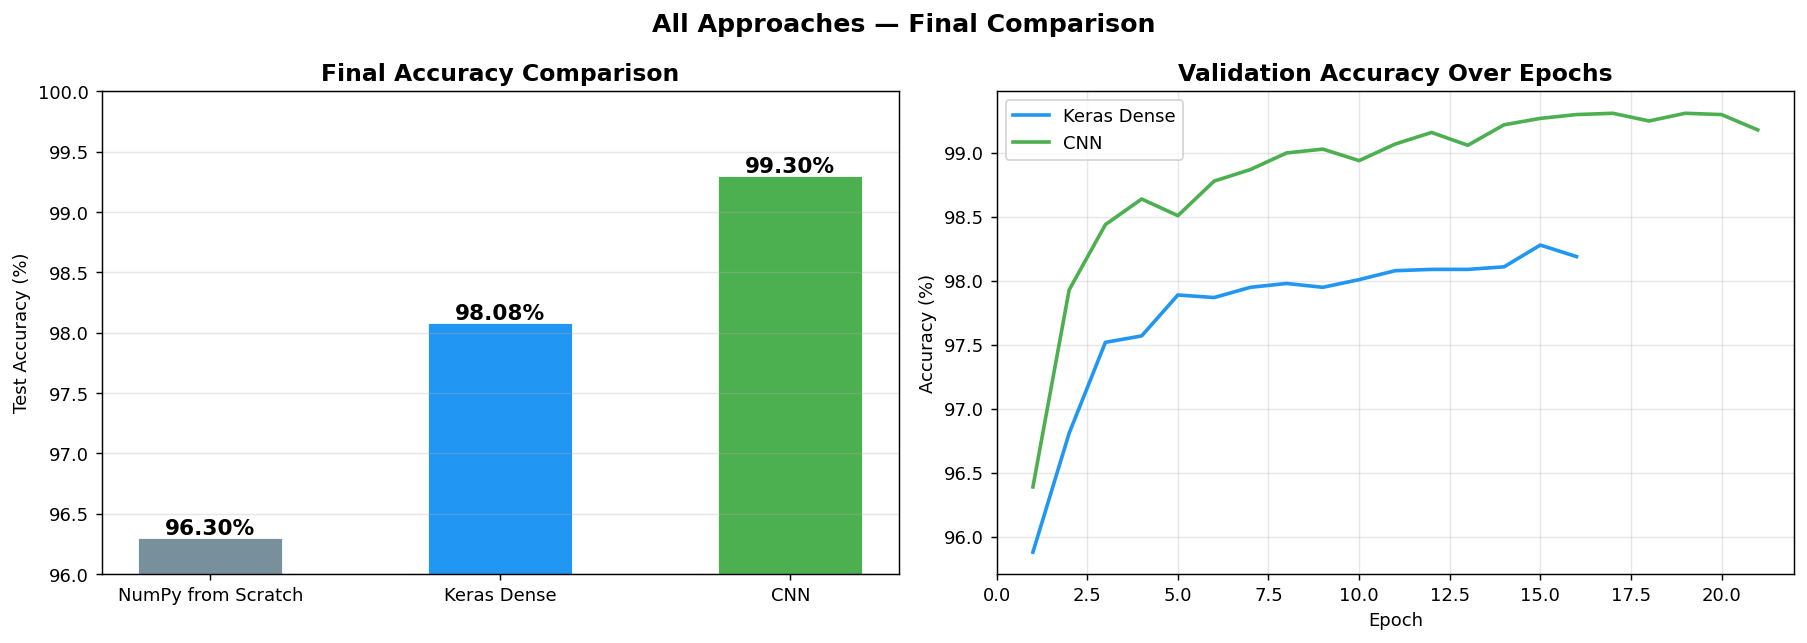

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
names  = list(comparison.keys())
accs   = [comparison[n]['acc']*100 for n in names]
colors = ['#78909C', '#2196F3', '#4CAF50']
bars = axes[0].bar(names, accs, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(96, 100)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Final Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Training curves
scratch_vals = [a*100 for a in arts.get('scratch_history', {}).get('val_acc', [])]
keras_vals   = [a*100 for a in arts['hist_best'].get('val_accuracy', [])]
cnn_vals     = [a*100 for a in hist_cnn.history['val_accuracy']]

for vals, color, label in zip(
    [scratch_vals, keras_vals, cnn_vals],
    colors, names
):
    if vals:
        axes[1].plot(range(1, len(vals)+1), vals, color=color, linewidth=2, label=label)

axes[1].set_title('Validation Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('All Approaches — Final Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMG + '03_final_comparison.png', bbox_inches='tight')
plt.show()

> **Key insight:** The CNN achieves the highest accuracy with *fewer* parameters than the dense networks — because convolutional filters are reused across all image positions (parameter sharing). The from-scratch implementation matches the Keras baseline almost exactly, which is a strong validation that our backpropagation code is correct. The CNN's advantage grows on harder image datasets — MNIST is simple enough that a dense network gets close to the ceiling.